In [1]:
from  langchain_openai import ChatOpenAI
import os 
from dotenv import load_dotenv

# This function will load all the variables from the .env file and will 
# make them available in the os.environ dictionary (env variables)
load_dotenv() 

if os.environ.get("OPENAI_API_KEY"):
    print("Bro API KEY Variable exists")
else:
    raise ValueError("OPENAI_API_KEY not found")

from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from  langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser

llm_openai = ChatOpenAI(model="gpt-5-mini",temperature=0)

Bro API KEY Variable exists


# ***Tools***

In [10]:
# Tool 1 - [News Search Tool]
from langchain_community.tools import DuckDuckGoSearchRun
search_tool = DuckDuckGoSearchRun(description="useful for when you want to search the internet")


# Tool 2 - [Wikipedia Search Tool]
from langchain_community.tools.wikidata.tool import WikidataAPIWrapper, WikidataQueryRun
wikidata_tool = WikidataQueryRun(api_wrapper=WikidataAPIWrapper(description="useful for when you want to search wikidata"))

# Tool 3 - [Custom Tool]
from langchain_core.tools import tool

@tool
def enterprise_tool(query: str) -> str:
    """This tool is used to send an email to the employee"""
    return "Email Sent"


# ***Tool Kit***

In [11]:
# Tool Kit
tool_kit = [search_tool, wikidata_tool, enterprise_tool]

# ***ReAct Agent***

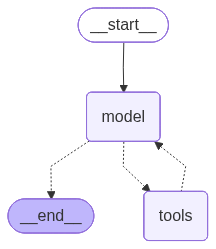

In [17]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI

model = ChatOpenAI(model_name="gpt-3.5-turbo", temperature=0, max_tokens=1000, timeout=10)

agent = create_agent(
    model,
    tools=tool_kit
)

agent



# ***ReAct Agent Invoke With Streams***

In [19]:
example_query = "Give me the latest news about the stock market"

events = agent.stream(
    {"messages": [("user", example_query)]},
    stream_mode="values",
)
for event in events:
    event["messages"][-1].pretty_print()



================================ Human Message =================================

Give me the latest news about the stock market
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (call_VA0Ps9mcm5ztWq4JbfjpfFwm)
 Call ID: call_VA0Ps9mcm5ztWq4JbfjpfFwm
  Args:
    query: latest news about the stock market
================================= Tool Message =================================
Name: duckduckgo_search

11 hours ago·The S&P/ASX 200 has now dropped 130 points or 1.42% to 9,070.00 at 3:15pm AEDT. Brent crude is up 2% in Asian trade to $US79.31. 14 hours ago·US equities declined in early tradingwhile oil prices spiked, as fighting entered its third day Monday. Shipping through the Strait of Hormuz, a chokepoint ... 4 days ago·Find the latest stock market news from every corner of the globe at Reuters.com, your online source for breaking international market and finance news. 17 hours ago·Tom Lee, Fundstrat Global Advisors 

# ***Manually Binding The LLM With Tools***

In [20]:
# Without Binding
llm_openai.invoke("What's the latest news about the stock market?")

AIMessage(content='I don’t have real‑time market access or live news after my knowledge cutoff (June 2024), so I can’t fetch “latest” headlines right now. Do you want a live update? If so, tell me which market or stocks (e.g., US S&P 500, Nasdaq, Dow, FTSE, Nikkei, or specific tickers) and I’ll tell you how to get current quotes and headlines or how to interpret them.\n\nIf you just want a quick checklist of what to look for in “latest” stock‑market news, here are the top items that typically move markets right now:\n\n- Major indices and futures (S&P 500, Nasdaq, Dow) and whether premarket/after‑hours action is showing follow‑through.\n- Treasury yields, especially the US 10‑year — moves in yields often drive sector rotation (growth vs value).\n- Central bank guidance (Fed statements, rate‑cut expectations or hikes) and economic data (CPI, PCE, unemployment, ISM).\n- Corporate earnings and guidance — big beats or misses from major tech, finance, energy names.\n- Sector news: tech/AI, 

In [22]:


# With Binding
llm_binded = llm_openai.bind_tools(tool_kit)
llm_binded.invoke("What's the latest news about the stock market?")



AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 163, 'prompt_tokens': 237, 'total_tokens': 400, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DFElVkrFKspDsHeq5wWx5kbS48STK', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cb2aa-9030-7682-8f72-565b80f303f1-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'stock market news today March 3 2026'}, 'id': 'call_T7fNJasIbgmgRP9DXWLSZHAI', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 237, 'output_tokens': 163, 'total_tokens': 400, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0,